# Vector Quantized Variational Autoencoder (VQVAE)

> *Neural Discrete Representation Learning* — van den Oord et al., 2017

## Motivation

A standard VAE encodes images into a **continuous** latent space z ∈ ℝⁿ.  
The VQVAE replaces it with a **discrete** latent space: each spatial position in the encoded feature map is mapped to the index of the nearest vector in a learned **codebook**.

```
Image  ──► Encoder ──► z_e  ──► Vector Quantization ──► z_q ──► Decoder ──► Reconstruction
                  (continuous)   (nearest codebook entry)  (discrete)
```

## Why discrete representations?
- More structured and compressed latent space
- Can be modelled with a discrete prior (e.g. PixelCNN, Transformer)
- Foundation of DALL-E 1, AudioLM, MusicLM

## The key challenge: non-differentiability

The `argmin` (nearest neighbour lookup) has **zero gradient**. The solution is the **straight-through estimator**:
during the backward pass, we pretend z_q = z_e and copy gradients directly from the decoder back to the encoder.

```python
z_q = z_e + (z_q - z_e).detach()   # forward: z_q  |  backward: gradient flows as if z_q == z_e
```

## Loss function (3 terms)

$$\mathcal{L} = \underbrace{\|x - \hat{x}\|^2}_{\text{reconstruction}} + \underbrace{\|\text{sg}[z_e] - e\|^2}_{\text{codebook loss}} + \beta \underbrace{\|z_e - \text{sg}[e]\|^2}_{\text{commitment loss}}$$

- **Reconstruction loss** — decoder produces images close to the input
- **Codebook loss** — moves codebook vectors `e` toward encoder outputs `z_e` (`sg` = stop gradient)
- **Commitment loss** — prevents the encoder from jumping between codebook entries (β = 0.25 typically)

## Step 1 — Imports & configuration

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# ── Hyperparameters ──────────────────────────────────────────────
BATCH_SIZE    = 128
EPOCHS        = 20
LR            = 2e-4

# Encoder output channels = codebook vector dimension
EMBEDDING_DIM = 64    # D : dimension of each codebook vector
NUM_EMBEDDINGS = 512  # K : number of vectors in the codebook
BETA          = 0.25  # commitment loss weight

Using device: cuda


## Step 2 — Dataset (FashionMNIST)

Same dataset as the VAE — good for direct comparison.
Images are 28×28 grayscale, padded to 32×32 so spatial dimensions divide evenly through the convolutions.

In [3]:
transform = transforms.Compose([
    transforms.Pad(2),                 # 28x28 → 32x32
    transforms.ToTensor(),             # [0,1]
    transforms.Normalize((0.5,), (0.5,))  # [-1, 1]  (helps reconstruction with tanh)
])

train_dataset = datasets.FashionMNIST(root='./data', train=True,  download=True, transform=transform)
val_dataset   = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train: {len(train_dataset):,} samples  |  Val: {len(val_dataset):,} samples')

Train: 60,000 samples  |  Val: 10,000 samples


## Step 3 — Encoder

The encoder maps an image `(B, 1, 32, 32)` to a feature map `(B, EMBEDDING_DIM, 8, 8)`.

Each of the **8×8 = 64 spatial positions** will be independently quantized — so the image is described by **64 discrete codes**.

```
(B, 1, 32, 32)  →  Conv(32) stride 2  →  (B, 32, 16, 16)
                →  Conv(64) stride 2  →  (B, 64, 8, 8)
                →  Conv(D)  stride 1  →  (B, D, 8, 8)     ← z_e
```

In [4]:
class Encoder(nn.Module):
    def __init__(self, in_channels: int, embedding_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            # 32x32 → 16x16
            nn.Conv2d(in_channels, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            # 16x16 → 8x8
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            # project to embedding_dim channels (no spatial downsampling)
            nn.Conv2d(64, embedding_dim, kernel_size=3, stride=1, padding=1),
        )

    def forward(self, x):
        return self.net(x)   # (B, D, 8, 8)


# Quick shape check
enc = Encoder(in_channels=1, embedding_dim=EMBEDDING_DIM)
dummy = torch.zeros(4, 1, 32, 32)
out = enc(dummy)
print(f'Encoder output: {out.shape}')   # should be (4, 64, 8, 8)

Encoder output: torch.Size([4, 64, 8, 8])


## Step 4 — Vector Quantization layer ⭐

This is the core of VQVAE. The codebook is a matrix `E` of shape `(K, D)` — K vectors of dimension D.

### Forward pass
1. Receive `z_e` of shape `(B, D, H, W)`
2. Reshape to `(B*H*W, D)` — treat every spatial position independently
3. Compute L2 distances between each position and every codebook vector
4. Pick the nearest: `k = argmin_k ||z_e - e_k||²`
5. Replace z_e with the codebook entry: `z_q = E[k]`
6. Apply **straight-through**: `z_q = z_e + (z_q - z_e).detach()`

### Distance trick (efficient computation)
$$\|a - b\|^2 = \|a\|^2 + \|b\|^2 - 2\, a \cdot b$$
This avoids materialising a huge `(B*H*W, K, D)` tensor.

In [5]:
class VectorQuantizer(nn.Module):
    def __init__(self, num_embeddings: int, embedding_dim: int, beta: float = 0.25):
        super().__init__()
        self.K   = num_embeddings
        self.D   = embedding_dim
        self.beta = beta

        # The codebook: K vectors of dimension D
        # Initialized from a uniform distribution
        self.embedding = nn.Embedding(self.K, self.D)
        self.embedding.weight.data.uniform_(-1 / self.K, 1 / self.K)

    def forward(self, z_e):
        """
        z_e : (B, D, H, W)  — encoder output
        returns:
            z_q      : (B, D, H, W)  — quantized (straight-through)
            loss     : scalar        — codebook + commitment loss
            indices  : (B, H, W)     — codebook indices (discrete codes)
        """
        B, D, H, W = z_e.shape

        # (B, D, H, W) → (B*H*W, D)  — flatten spatial dims
        z_flat = z_e.permute(0, 2, 3, 1).contiguous().view(-1, D)

        # ── Compute distances: ||z - e||² = ||z||² + ||e||² - 2*z·eᵀ ──
        d = (
            z_flat.pow(2).sum(dim=1, keepdim=True)          # (N, 1)
            + self.embedding.weight.pow(2).sum(dim=1)        # (K,)
            - 2 * z_flat @ self.embedding.weight.t()         # (N, K)
        )  # result: (N, K)

        # ── Nearest codebook entry ──
        indices_flat = d.argmin(dim=1)                       # (N,)
        indices = indices_flat.view(B, H, W)                 # (B, H, W)

        # ── Look up codebook vectors ──
        z_q_flat = self.embedding(indices_flat)              # (N, D)
        z_q = z_q_flat.view(B, H, W, D).permute(0, 3, 1, 2) # (B, D, H, W)

        # ── Loss ──
        # codebook loss  : moves e toward z_e  (stop gradient on z_e)
        # commitment loss: moves z_e toward e  (stop gradient on e)
        codebook_loss   = F.mse_loss(z_q.detach(), z_e)
        commitment_loss = F.mse_loss(z_q, z_e.detach())
        vq_loss = codebook_loss + self.beta * commitment_loss

        # ── Straight-through estimator ──
        # Forward : z_q (quantized)   |   Backward : gradient flows through z_e
        z_q = z_e + (z_q - z_e).detach()

        return z_q, vq_loss, indices


# Quick check
vq = VectorQuantizer(NUM_EMBEDDINGS, EMBEDDING_DIM, BETA)
z_e_dummy = torch.randn(4, EMBEDDING_DIM, 8, 8)
z_q_dummy, loss_dummy, idx_dummy = vq(z_e_dummy)
print(f'z_q shape  : {z_q_dummy.shape}')   # (4, 64, 8, 8)
print(f'indices    : {idx_dummy.shape}')    # (4, 8, 8)  — discrete codes
print(f'VQ loss    : {loss_dummy.item():.4f}')

z_q shape  : torch.Size([4, 64, 8, 8])
indices    : torch.Size([4, 8, 8])
VQ loss    : 1.2398


## Step 5 — Decoder

Mirror of the encoder. Takes `z_q` of shape `(B, D, 8, 8)` and reconstructs the image `(B, 1, 32, 32)`.

We use **Tanh** as final activation since images are normalized to [-1, 1].

```
(B, D, 8, 8)  →  ConvTranspose(64) stride 2  →  (B, 64, 16, 16)
              →  ConvTranspose(32) stride 2  →  (B, 32, 32, 32)
              →  Conv(1)           stride 1  →  (B,  1, 32, 32)  ← x̂
```

In [6]:
class Decoder(nn.Module):
    def __init__(self, embedding_dim: int, out_channels: int):
        super().__init__()
        self.net = nn.Sequential(
            # 8x8 → 16x16
            nn.ConvTranspose2d(embedding_dim, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            # 16x16 → 32x32
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            # final projection to image channels
            nn.Conv2d(32, out_channels, kernel_size=3, stride=1, padding=1),
            nn.Tanh(),  # output in [-1, 1]
        )

    def forward(self, z_q):
        return self.net(z_q)   # (B, 1, 32, 32)


# Shape check
dec = Decoder(EMBEDDING_DIM, out_channels=1)
recon = dec(z_q_dummy)
print(f'Decoder output: {recon.shape}')   # (4, 1, 32, 32)

Decoder output: torch.Size([4, 1, 32, 32])


## Step 6 — Full VQVAE model

Assembles Encoder → VectorQuantizer → Decoder.

The total loss is:
$$\mathcal{L} = \mathcal{L}_{\text{recon}} + \mathcal{L}_{\text{VQ}}$$

where $\mathcal{L}_{\text{VQ}}$ already contains both the codebook and commitment terms.

In [7]:
class VQVAE(nn.Module):
    def __init__(self, in_channels, embedding_dim, num_embeddings, beta):
        super().__init__()
        self.encoder    = Encoder(in_channels, embedding_dim)
        self.vq         = VectorQuantizer(num_embeddings, embedding_dim, beta)
        self.decoder    = Decoder(embedding_dim, in_channels)

    def forward(self, x):
        z_e          = self.encoder(x)           # continuous latent
        z_q, vq_loss, indices = self.vq(z_e)     # quantized latent + loss + codes
        x_hat        = self.decoder(z_q)          # reconstruction
        return x_hat, vq_loss, indices

    @torch.no_grad()
    def encode(self, x):
        """Returns the discrete codebook indices for a batch of images."""
        z_e = self.encoder(x)
        _, _, indices = self.vq(z_e)
        return indices   # (B, 8, 8)

    @torch.no_grad()
    def decode_indices(self, indices):
        """Reconstructs images from codebook indices."""
        B, H, W = indices.shape
        z_q = self.vq.embedding(indices.view(-1))        # (B*H*W, D)
        z_q = z_q.view(B, H, W, -1).permute(0, 3, 1, 2) # (B, D, H, W)
        return self.decoder(z_q)


model = VQVAE(
    in_channels    = 1,
    embedding_dim  = EMBEDDING_DIM,
    num_embeddings = NUM_EMBEDDINGS,
    beta           = BETA,
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f'Model parameters: {total_params:,}')

# Full forward pass check
x_dummy = torch.randn(4, 1, 32, 32).to(device)
x_hat, vq_loss, idx = model(x_dummy)
print(f'x_hat shape : {x_hat.shape}')   # (4, 1, 32, 32)
print(f'codes shape : {idx.shape}')     # (4, 8, 8)

Model parameters: 201,761
x_hat shape : torch.Size([4, 1, 32, 32])
codes shape : torch.Size([4, 8, 8])


## Step 7 — Training

The optimizer only touches the model parameters — the VQ loss takes care of training the codebook internally via stop-gradient.

We track:
- **recon_loss** — how well the decoder reconstructs images
- **vq_loss** — codebook + commitment
- **codebook usage** — how many of the K=512 entries are actually used ("codebook collapse" if this drops low)

In [8]:
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

history = {'train_recon': [], 'train_vq': [], 'val_recon': [], 'val_vq': [], 'codebook_usage': []}


def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_recon, total_vq, total_usage = 0.0, 0.0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()

    with ctx:
        for x, _ in loader:
            x = x.to(device)
            x_hat, vq_loss, indices = model(x)

            recon_loss = F.mse_loss(x_hat, x)
            loss = recon_loss + vq_loss

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_recon += recon_loss.item()
            total_vq    += vq_loss.item()
            # count unique codebook entries used in this batch
            total_usage += indices.unique().numel()

    n = len(loader)
    return total_recon / n, total_vq / n, total_usage // n


for epoch in range(1, EPOCHS + 1):
    tr_r, tr_vq, usage = run_epoch(train_loader, train=True)
    va_r, va_vq, _     = run_epoch(val_loader,   train=False)

    history['train_recon'].append(tr_r)
    history['train_vq'].append(tr_vq)
    history['val_recon'].append(va_r)
    history['val_vq'].append(va_vq)
    history['codebook_usage'].append(usage)

    print(f'Epoch {epoch:02d}/{EPOCHS} | '
          f'recon {tr_r:.4f}/{va_r:.4f} | '
          f'vq {tr_vq:.4f}/{va_vq:.4f} | '
          f'codebook usage {usage}/{NUM_EMBEDDINGS}')

Epoch 01/20 | recon 0.1963/0.0804 | vq 1.2732/0.2037 | codebook usage 15/512
Epoch 02/20 | recon 0.0671/0.0578 | vq 0.1110/0.0498 | codebook usage 16/512
Epoch 03/20 | recon 0.0517/0.0470 | vq 0.0361/0.0258 | codebook usage 21/512
Epoch 04/20 | recon 0.0437/0.0416 | vq 0.0222/0.0199 | codebook usage 25/512
Epoch 05/20 | recon 0.0393/0.0378 | vq 0.0191/0.0180 | codebook usage 28/512
Epoch 06/20 | recon 0.0358/0.0348 | vq 0.0172/0.0164 | codebook usage 32/512
Epoch 07/20 | recon 0.0330/0.0322 | vq 0.0159/0.0155 | codebook usage 35/512
Epoch 08/20 | recon 0.0308/0.0302 | vq 0.0153/0.0152 | codebook usage 37/512
Epoch 09/20 | recon 0.0291/0.0288 | vq 0.0153/0.0153 | codebook usage 40/512
Epoch 10/20 | recon 0.0278/0.0275 | vq 0.0154/0.0152 | codebook usage 43/512
Epoch 11/20 | recon 0.0265/0.0263 | vq 0.0151/0.0149 | codebook usage 46/512
Epoch 12/20 | recon 0.0254/0.0253 | vq 0.0148/0.0146 | codebook usage 49/512
Epoch 13/20 | recon 0.0245/0.0245 | vq 0.0145/0.0146 | codebook usage 52/512

## Step 8 — Training curves

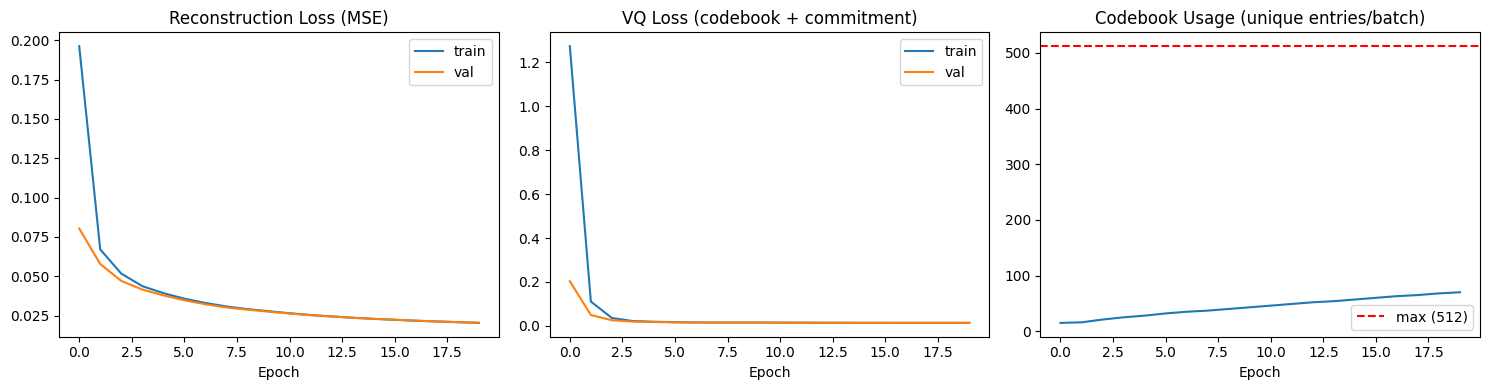

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history['train_recon'], label='train')
axes[0].plot(history['val_recon'],   label='val')
axes[0].set_title('Reconstruction Loss (MSE)')
axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(history['train_vq'], label='train')
axes[1].plot(history['val_vq'],   label='val')
axes[1].set_title('VQ Loss (codebook + commitment)')
axes[1].set_xlabel('Epoch'); axes[1].legend()

axes[2].plot(history['codebook_usage'])
axes[2].axhline(NUM_EMBEDDINGS, color='r', linestyle='--', label=f'max ({NUM_EMBEDDINGS})')
axes[2].set_title('Codebook Usage (unique entries/batch)')
axes[2].set_xlabel('Epoch'); axes[2].legend()

plt.tight_layout()
plt.show()

## Step 9 — Reconstruction quality

Compare original images (top) with their reconstructions (bottom).

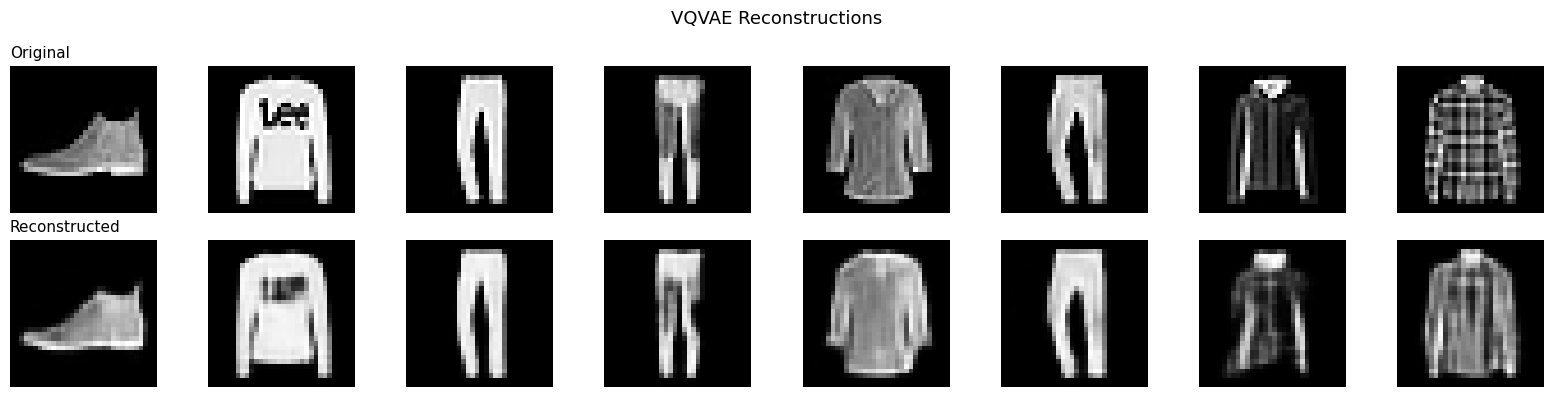

In [10]:
model.eval()
x_sample, _ = next(iter(val_loader))
x_sample = x_sample[:8].to(device)

with torch.no_grad():
    x_recon, _, _ = model(x_sample)

# Denormalize [-1,1] → [0,1]
to_img = lambda t: (t.cpu() * 0.5 + 0.5).clamp(0, 1)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(8):
    axes[0, i].imshow(to_img(x_sample[i]).squeeze(), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(to_img(x_recon[i]).squeeze(), cmap='gray')
    axes[1, i].axis('off')

axes[0, 0].set_title('Original', loc='left', fontsize=11)
axes[1, 0].set_title('Reconstructed', loc='left', fontsize=11)
plt.suptitle('VQVAE Reconstructions', fontsize=13)
plt.tight_layout()
plt.show()

## Step 10 — Visualising the discrete codebook indices

Each image is compressed into an **8×8 grid of integers** (from 0 to 511).  
This is the discrete representation — the "token map" of the image.

This is exactly what DALL-E 1 uses: it first encodes images into token maps like these, then trains a Transformer to generate them.

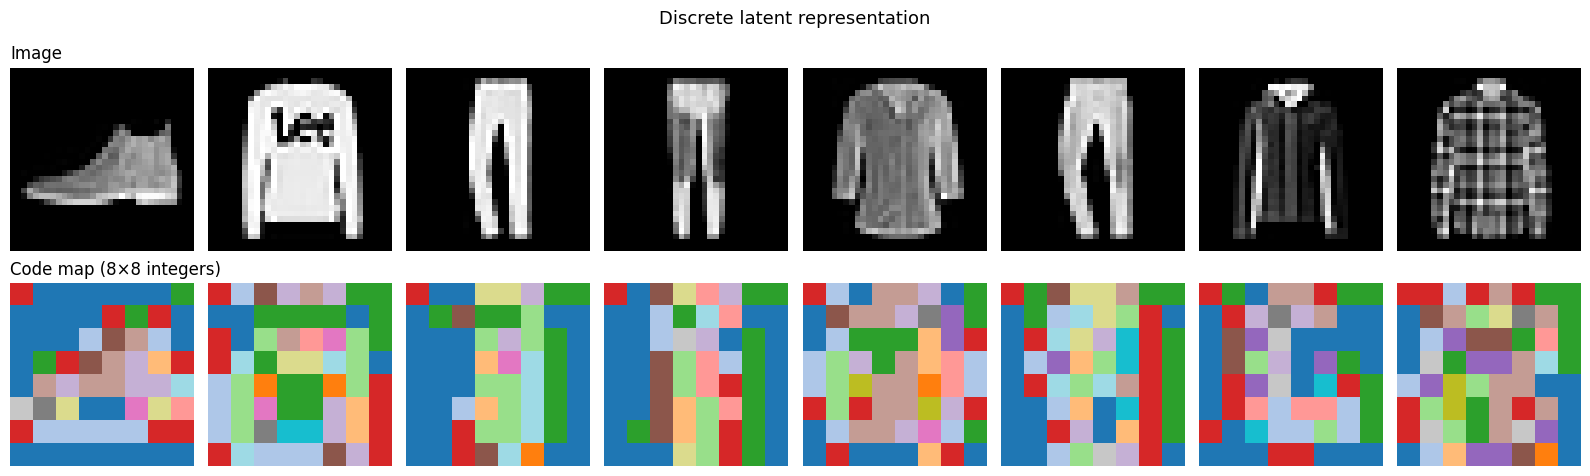

Compression: 32×32 = 1024 pixels  →  8×8 = 64 integers (each in [0, 511])
Compression ratio: 16×


In [11]:
with torch.no_grad():
    codes = model.encode(x_sample)   # (8, 8, 8) — 8 images, each 8x8 codes

fig, axes = plt.subplots(2, 8, figsize=(16, 5))
for i in range(8):
    # Original image
    axes[0, i].imshow(to_img(x_sample[i]).squeeze(), cmap='gray')
    axes[0, i].axis('off')

    # Codebook index map
    axes[1, i].imshow(codes[i].cpu().numpy(), cmap='tab20', vmin=0, vmax=NUM_EMBEDDINGS)
    axes[1, i].axis('off')

axes[0, 0].set_title('Image', loc='left')
axes[1, 0].set_title('Code map (8×8 integers)', loc='left')
plt.suptitle('Discrete latent representation', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Compression: 32×32 = 1024 pixels  →  8×8 = 64 integers (each in [0, {NUM_EMBEDDINGS-1}])')
print(f'Compression ratio: {1024 / 64:.0f}×')

## Step 11 — Codebook interpolation

Because the latent space is **discrete**, classical interpolation (like in a VAE) doesn't make sense.  
Instead, we can mix the **code maps** of two images and decode the result.

For each spatial position, we randomly pick the code from image A or image B — producing a hybrid.

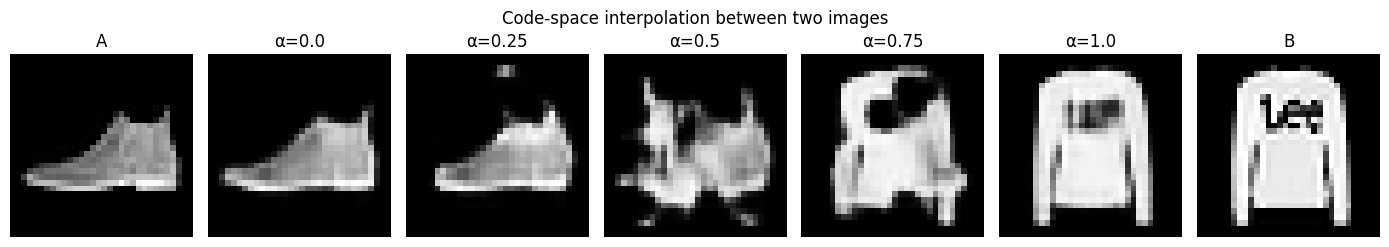

In [12]:
with torch.no_grad():
    codes_all = model.encode(x_sample)   # (8, 8, 8)

# Mix codes of image 0 and image 1 with different ratios
alphas = [0.0, 0.25, 0.5, 0.75, 1.0]
n_interp = len(alphas)

fig, axes = plt.subplots(1, n_interp + 2, figsize=(14, 2.5))

axes[0].imshow(to_img(x_sample[0]).squeeze(), cmap='gray'); axes[0].set_title('A'); axes[0].axis('off')
axes[-1].imshow(to_img(x_sample[1]).squeeze(), cmap='gray'); axes[-1].set_title('B'); axes[-1].axis('off')

for j, alpha in enumerate(alphas):
    mask = (torch.rand(8, 8) < alpha).to(device)   # True → take from B
    mixed_codes = torch.where(mask, codes_all[1], codes_all[0]).unsqueeze(0)   # (1, 8, 8)
    with torch.no_grad():
        hybrid = model.decode_indices(mixed_codes)   # (1, 1, 32, 32)
    axes[j + 1].imshow(to_img(hybrid[0]).squeeze(), cmap='gray')
    axes[j + 1].set_title(f'α={alpha}')
    axes[j + 1].axis('off')

plt.suptitle('Code-space interpolation between two images', fontsize=12)
plt.tight_layout()
plt.show()

## Summary

| Component | Role |
|-----------|------|
| Encoder | Maps image (32×32) → continuous feature map (8×8×D) |
| VectorQuantizer | Replaces each D-vector with its nearest codebook entry → discrete index |
| Straight-through | Copies gradient from decoder back to encoder, bypassing the non-differentiable argmin |
| Codebook loss | Pulls codebook vectors toward encoder outputs |
| Commitment loss | Pulls encoder outputs toward codebook vectors (prevents instability) |
| Decoder | Reconstructs image from quantized feature map |

## What's next?

Once a VQVAE is trained, the discrete code maps `(H×W integers)` can be modelled with a **Transformer or PixelCNN** as a prior — this gives you a fully generative model. That is exactly how **DALL-E 1** works:

```
Text prompt → Transformer → code map (discrete) → VQVAE decoder → image
```

The next natural step in the portfolio would be to train a small PixelCNN on top of these code maps to enable **unconditional generation**.